# Brain Tumor MRI Dataset — Exploration

Quick exploratory data analysis before training. Run `python src/data_download.py` from the project root first so `data/Training` and `data/Testing` exist.

In [5]:
%pip install matplotlib


  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
      --------------------------------------- 0.2/12.9 MB 7.0 MB/s eta 0:00:02
     - -------------------------------------- 0.6/12.9 MB 8.1 MB/s eta 0:00:02
     --- ------------------------------------ 1.2/12.9 MB 8.4 MB/s eta 0:00:02
     ----- ---------------------------------- 1.8/12.9 MB 9.7 MB/s eta 0:00:02
     ------- -------------------------------- 2.5/12.9 MB 11.5 MB/s eta 0:00:01
     ---------- ----------------------------- 3.3/12.9 MB 12.4 MB/s eta 0:00:01
     ------------- -------------------------- 4.3/12.9 MB 13.6 MB/s eta 0:00:01
     --------------- ------------------------ 5.1/12.9 MB 14.3 MB/s eta 0:00:01
     ---------------- ----------------------- 5.4/12.9 MB 13.8 MB/s eta 0:00:01
     ----------------


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_DIR = DATA_DIR / "Training"
TEST_DIR = DATA_DIR / "Testing"
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

assert TRAIN_DIR.exists(), "Run `python src/data_download.py` from the project root first."

## Class distribution


Training:
  glioma       1400
  meningioma   1400
  notumor      1400
  pituitary    1400


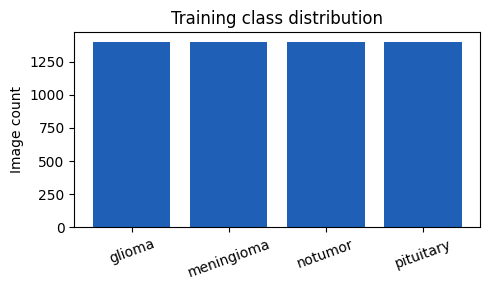


Testing:
  glioma       400
  meningioma   400
  notumor      400
  pituitary    400


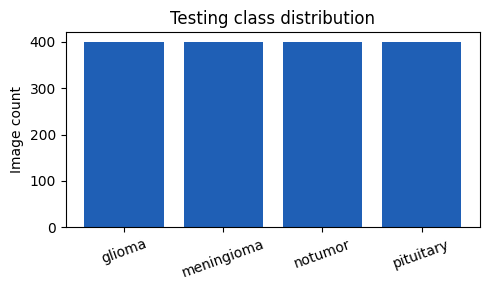

In [7]:
for split_name, split_dir in [("Training", TRAIN_DIR), ("Testing", TEST_DIR)]:
    print(f"\n{split_name}:")
    counts = {}
    for cls in CLASSES:
        cls_dir = split_dir / cls
        n = len(list(cls_dir.glob("*"))) if cls_dir.exists() else 0
        counts[cls] = n
        print(f"  {cls:<12} {n}")
    plt.figure(figsize=(5, 3))
    plt.bar(counts.keys(), counts.values(), color="#1f5fb5")
    plt.title(f"{split_name} class distribution")
    plt.ylabel("Image count")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

## Sample images per class

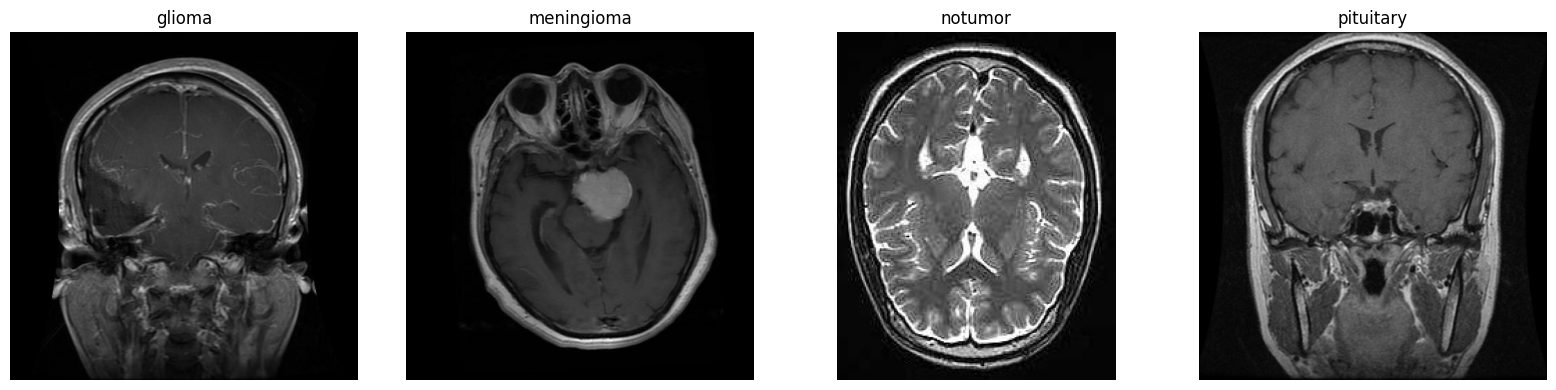

In [8]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 4))
for ax, cls in zip(axes, CLASSES):
    cls_dir = TRAIN_DIR / cls
    sample_path = next(cls_dir.glob("*"))
    img = Image.open(sample_path)
    ax.imshow(img, cmap="gray")
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Image size variability

The dataset description notes that raw image dimensions vary across samples — this is why `ImageDataGenerator` resizes every image to a fixed `(224, 224)` target size during training (see `src/train.py`).

In [9]:
import random

sizes = []
for cls in CLASSES:
    cls_dir = TRAIN_DIR / cls
    files = list(cls_dir.glob("*"))
    sample = random.sample(files, min(20, len(files)))
    for f in sample:
        with Image.open(f) as im:
            sizes.append(im.size)

widths, heights = zip(*sizes)
print(f"Width  range: {min(widths)} - {max(widths)}")
print(f"Height range: {min(heights)} - {max(heights)}")

Width  range: 150 - 926
Height range: 168 - 649
